In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import random

def demp(X, x):
    X = np.sort(X)
    a = -1
    b = len(X)
    m = (a + b) // 2

    while a + 1 < b:
        if X[m] > x:
            b = m
        else:
            a = m
        m = (a + b) // 2

    return (a + 1) / len(X)

set_x = [1, 2, 3,3]

print(demp(set_x, 2))


0.5


2. Napisz funkcję drawdemp(X), rysującą wykres dystrybuanty empirycznej dla
sensownego przedziału próby X. Unikaj użycia funkcji step.

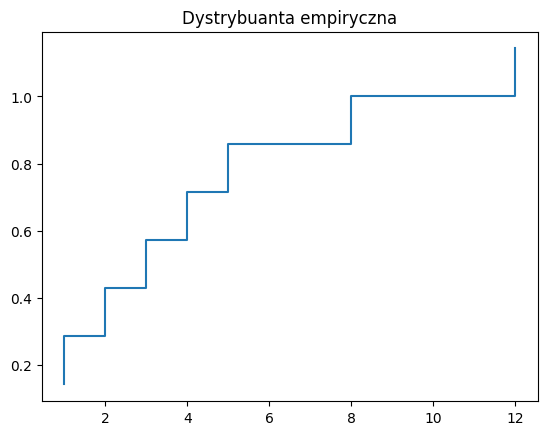

In [402]:
def drawdemp(X, title = 'Dystrybuanta empiryczna'):
    X = np.sort(np.array(X))
    n = len(X)
    dx = 0.000001
    y = np.linspace(1/n, 1, n)
    y = np.repeat(y, 2)
    x = np.empty(2*n)
    x[0::2] = X
    x[1::2] = X + dx
    y[1::2] += 1/n
    plt.plot(x, y)
    plt.title(title)

u = [1, 3, 4, 2, 5, 8, 12]

drawdemp(u)

### 3. Wygeneruj N = 1000 zmiennych z rozkładu Exp(1) (wbudowanym generatorem). 
Narysuj na jednym wykresie dystrybuantę empiryczną i teoretyczną.
Powtórz dla N = 50 i N = 10 000

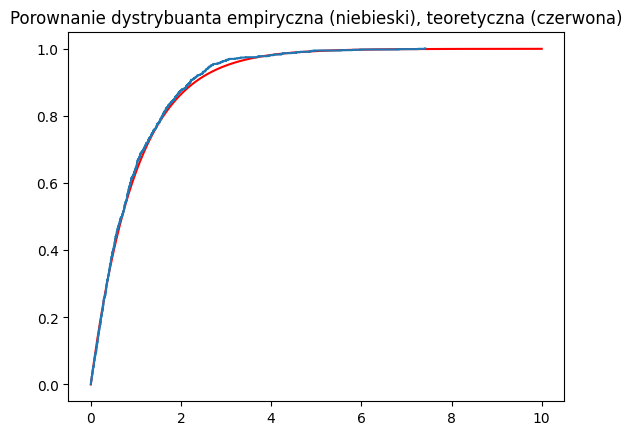

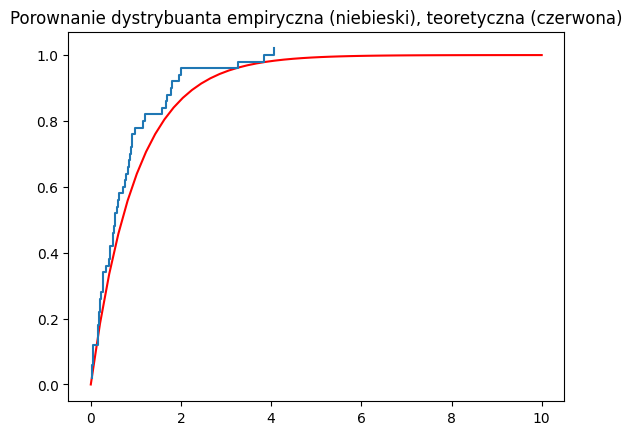

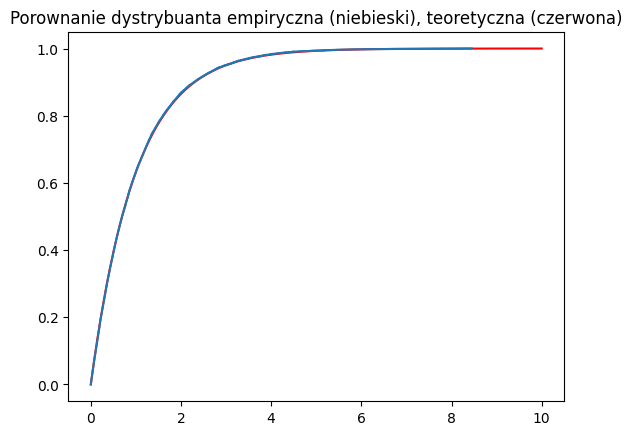

In [403]:
N = [1000, 50, 10000]

for n in N:
    y = np.random.exponential(scale=1, size=n)
    x = np.linspace(0, 10, n)
    y_distr = 1 - np.exp(-1*x)
    plt.plot(x, y_distr, color='red')
    drawdemp(sorted(y),'Porownanie dystrybuanta empiryczna (niebieski), teoretyczna (czerwona)')
    plt.show()


### Zadanie 4 – numeryczne odwracanie dystrybuanty

In [404]:
def rev_distr(F, t, a = -100000, b = 100000, dx = 1e-3):
    while b - a > dx:
        x = 0.5 * (a + b)
        diff = F(x) - t
        if diff > 0:
            b = x
        else:
            a = x
    return 0.5 * (a + b)

In [405]:
def rev_discrete_distr(F, t, a = -100000, b = 100000, dx = 1e-3):
    x = (a + b) // 2
    while b - a > 1:
        x = (a + b) // 2
        diff = F(x) - t
        if diff > 0:
            b = x
        else:
            a = x
    return b

In [406]:
import math

def exp_distr(x, lam):
    return 1 - np.exp(-x*lam)

def norm_distr(x, mu=0, sigma=1):
    return 0.5*(1 + sc.special.erf((x-mu)/(sigma*np.sqrt(2))))

def cauchy_distr(x, mi, gamma):
    return 1 / np.pi*np.arctan((x-mi) / gamma) + 1/2

def geo_distr(k, p):
    return 1 - (1 - p)**math.ceil(k)

def poisson_distr(k, lam):
    s = 0.0
    for j in range(math.floor(k+1)):
        s += np.exp(-lam)* lam**j / (math.factorial(j))
    return s

def defined_distr(x):
    if x < 1:
        return 0
    elif x < 3:
        return 3/7
    elif x < 10:
        return 1/2
    else:
        return 1

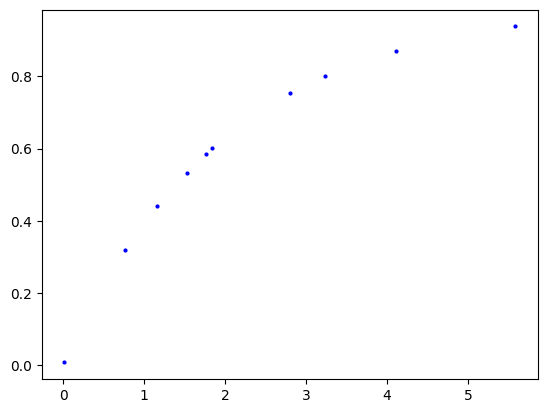

Skala różnicy: [1.54637178e-06 2.02990900e-06 6.42162271e-07 9.52726646e-07
 1.86866925e-06 1.21237139e-06 1.31224480e-07 2.32204795e-07
 1.48355473e-06 2.63100363e-06]


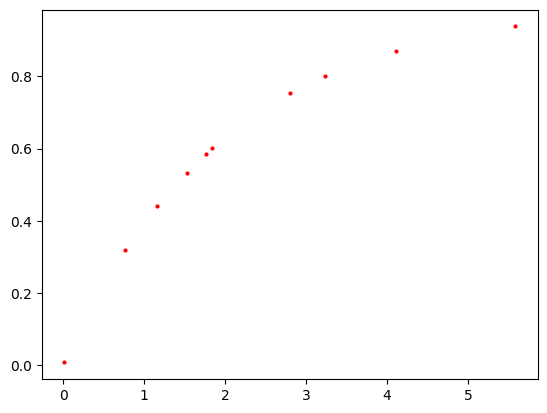

In [407]:
lam = 1/2
U = np.random.random(10)
X_exp = -1 / lam * (np.log(1 - U))
X_exp_2 = []
F = lambda x: exp_distr(x, lam) # równoznaczne z def F(x): return exp_distr(x, lam)

for u in U:
    X_exp_2.append(rev_distr(F, u, 0, dx=1e-5)) # zmniejszanie dx zmniejsza skalę błędu
plt.plot(X_exp, U, 'bo', markersize=2) # teoretyczne F^-1
plt.show()
plt.plot(X_exp_2, U, 'ro', markersize=2) # numeryczne F^-1
diff = abs(X_exp_2 - X_exp)
print(f'Skala różnicy: {diff}')
plt.show()

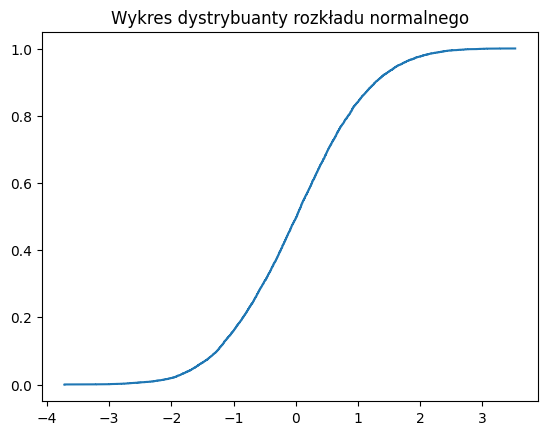

In [408]:
U = np.random.random(10000)
X_norm = []
for u in U:
    X_norm.append(rev_distr(norm_distr, u))
drawdemp(X_norm,'Wykres dystrybuanty rozkładu normalnego')
plt.show()

### Zadanie 5 – narzędzia do weryfikacji (QQ PLOT)

In [409]:
def drawqq(X, distr, title='QQ Plot'):
    X = np.sort(X)
    n = len(X)
    Q = np.empty(n)
    for i in range(1, n):
        q = rev_distr(distr, i / n, a = -1e5, b = 1e5)
        Q[i-1] = q
    plt.plot(Q, X, 'go', markersize=2)
    x = np.linspace(min(X), max(X), n)
    plt.plot(x,x)
    plt.title(title)
    plt.show()

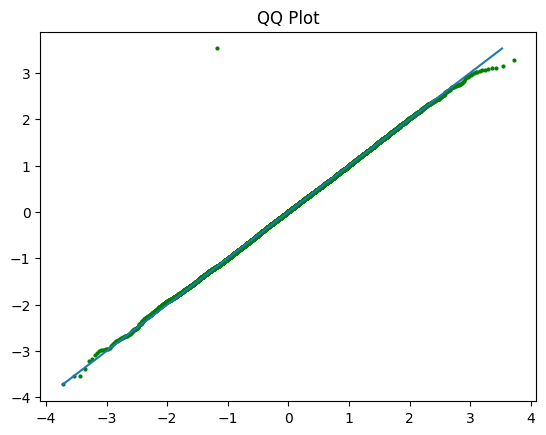

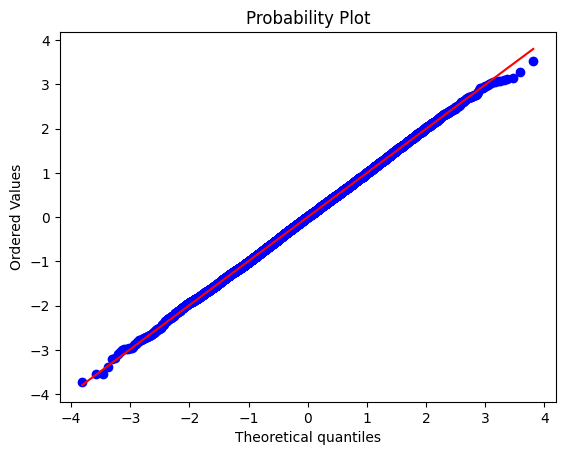

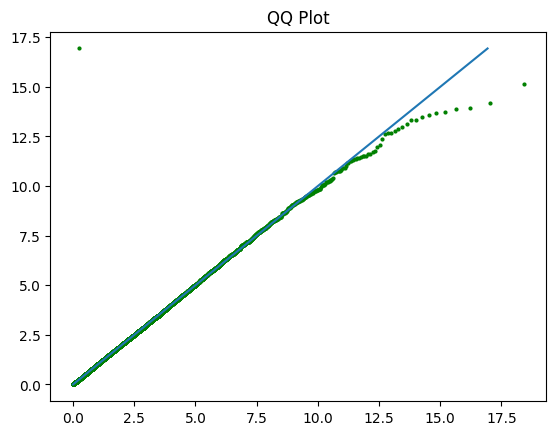

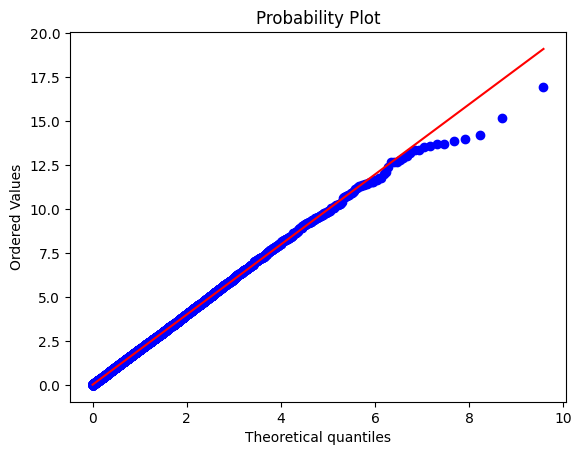

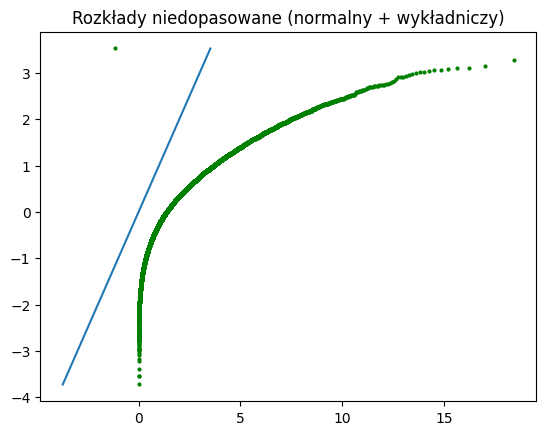

In [410]:
drawqq(X_norm, norm_distr)
sc.stats.probplot(X_norm, dist='norm', plot=plt)
plt.show()

X_exp = []
for u in U:
    X_exp.append(rev_distr(F, u, 0, dx=1e-5))
drawqq(X_exp, F)
sc.stats.probplot(X_exp, dist='expon', plot=plt)
plt.show()

drawqq(X_norm, F, title='Rozkłady niedopasowane (normalny + wykładniczy)')

In [411]:
def BCD(a, b):
    k = a % b
    if k == 0:
        return b
    return BCD(b, k)

def SCD(a, b):
    return a * b / BCD(a, b)

def table_lookup(a_k, b_k, x_k):
    b1 = 1
    for b2 in b_k:
        b1 = SCD(b1, b2)
    
    b1 = int(b1)
    table = np.empty(b1)

    for i in range(len(a_k)):
        n = b1 / b_k[i]
        a_k[i] *= n
    
    index = 0
    for k in range(len(a_k)):
        while a_k[k] > 0:
            a_k[k] -= 1
            table[index] = x_k[k]
            index += 1
    return table

def fixed_prob(table):
    n = len(table)
    U = math.floor(random.random()* n)
    return table[U]


6. Dla każdego poniższego rozkładu narysuj histogram i gęstość teoretyczną lub funkcję
prawdopodobieństwa dla rozkładów dyskretnych (na jednym wykresie).

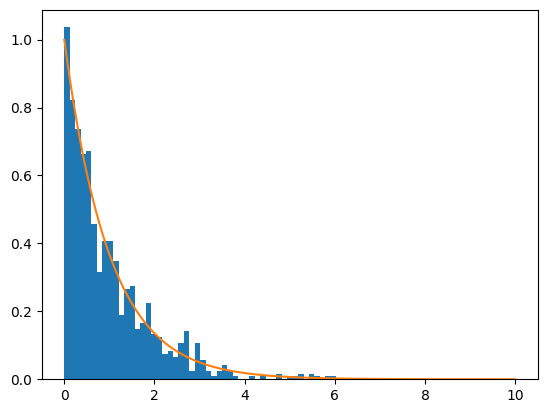

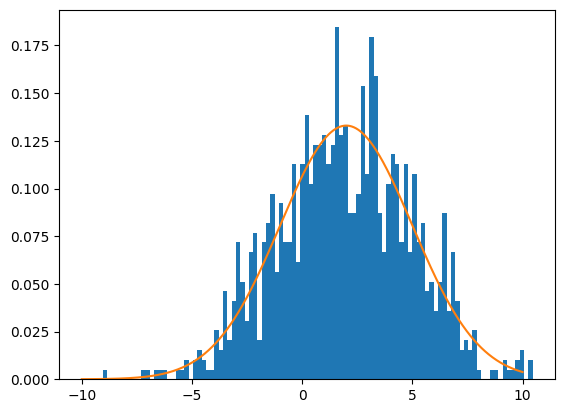

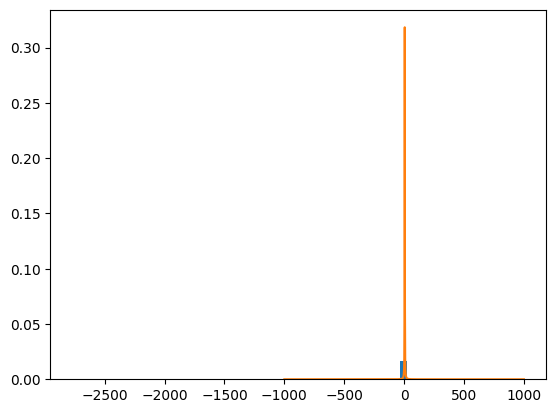

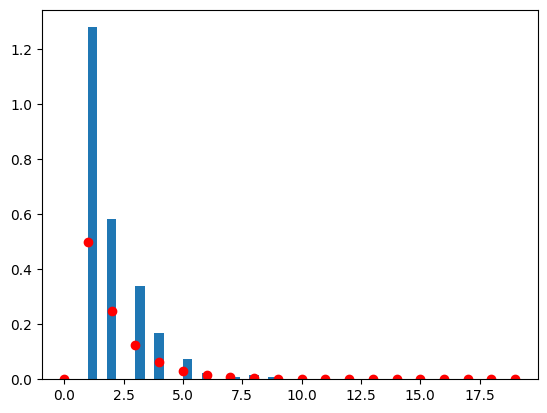

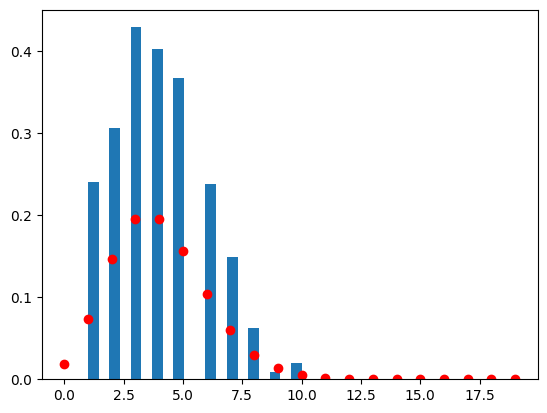

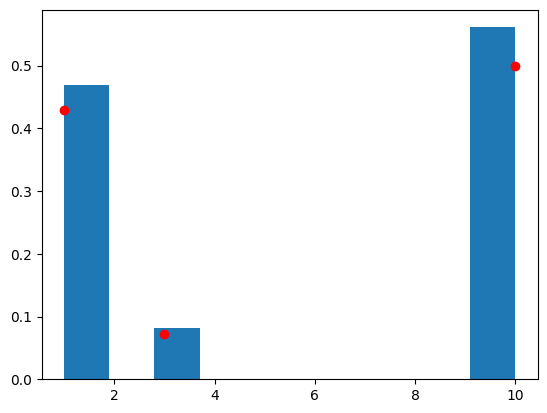

In [412]:
N = 1000
U = np.random.random(N)

a_k = [3, 1, 1]
b_k = [7, 14, 2]
x_k = [1, 3, 10]
y_k = np.array(a_k) / np.array(b_k)

prob_table = table_lookup(a_k, b_k, x_k)

# empiryczne wartości
y_exp = np.empty(N)
y_norm = np.empty(N)
y_cauchy = np.empty(N)
y_geo = np.empty(N)
y_poiss = np.empty(N)
y_fixed_prob = np.empty(N)

# teoretyczne gęstości
x_norm = np.linspace(-10, 10, N)
x_exp = np.linspace(0, 10, N)
x_cauchy = np.linspace(-1000, 1000, N)

n = np.arange(0, 20, 1)
y1 = sc.stats.expon.pdf(x_exp, scale=1)
y2 = sc.stats.norm.pdf(x_norm, loc=2, scale=3)
y3 = sc.stats.cauchy.pdf(x_cauchy, 5, 1)

y4 = sc.stats.geom.pmf(n, 1/2)
y5 = sc.stats.poisson.pmf(n, 4)

for i in range(N):
    u = U[i]
    F1 = lambda x: exp_distr(x, 1)
    F2 = lambda x: norm_distr(x, 2, 3)
    F3 = lambda x: cauchy_distr(x, 5, 1)
    F4 = lambda k: geo_distr(k, 1/2)
    F5 = lambda k: poisson_distr(k, 4)
    y_exp[i] = rev_distr(F1, u, a = 0)
    y_norm[i] = rev_distr(F2, u)
    y_cauchy[i] = rev_distr(F3, u)
    y_geo[i] = rev_discrete_distr(F4, u, a = 0)
    y_poiss[i] = rev_discrete_distr(F5, u, a=0, b = 10)
    y_fixed_prob[i] = fixed_prob(prob_table)

plt.hist(y_exp, bins=50, density=True)
plt.plot(x_exp, y1)
plt.show()
plt.hist(y_norm,bins=100, density=True)
plt.plot(x_norm, y2)
plt.show()
plt.hist(y_cauchy,bins=50, density=True)
plt.plot(x_cauchy, y3)
plt.show()
plt.hist(y_geo,bins=20, density=True)
plt.plot(n, y4, 'ro')
plt.show()
plt.hist(y_poiss,bins=20, density=True)
plt.plot(n, y5, 'ro')
plt.show()
plt.hist(y_fixed_prob, bins=10, density=True) # ten się zmieni
plt.plot(x_k, y_k, 'ro')
plt.show()


### 7. WERYFIKACJA GENERATORA

### 1. Histogram i gęstość teoretyczna przedstawione na jednym wykresie

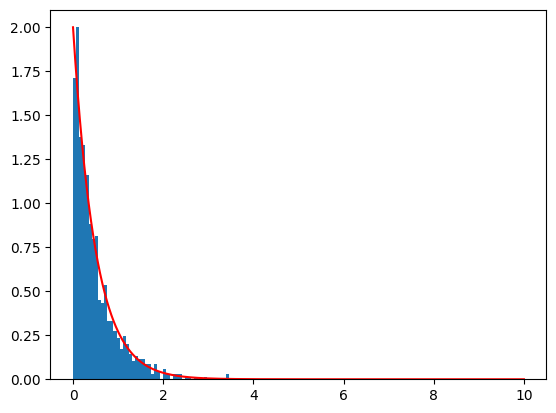

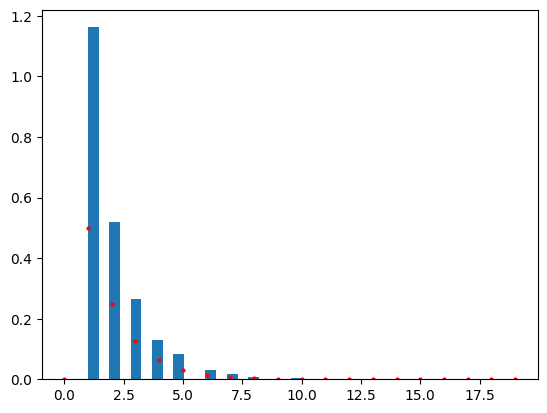

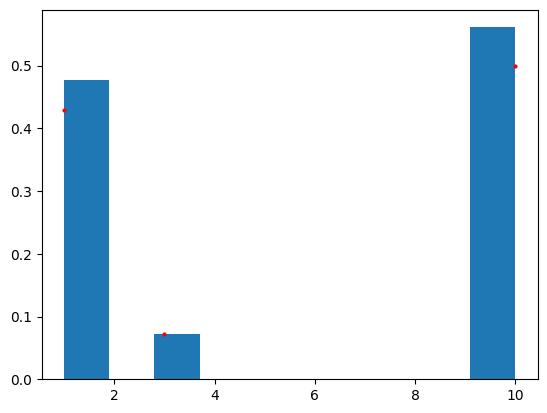

In [413]:
N = 1000
U = np.random.random(N)

a_k = [3, 1, 1]
b_k = [7, 14, 2]
x_k = [1, 3, 10]
y_prob = np.array(a_k) / np.array(b_k)
prob_table = table_lookup(a_k, b_k, x_k)

F_E = lambda x: exp_distr(x, 2)
F_G = lambda x: geo_distr(x, 0.5)
F_K = np.array(a_k) / np.array(b_k)
Y = [[], [], []]

x1 = np.linspace(0, 10, N)
x2 = np.arange(0, 20, 1)
x3 = x_k

x_theory = [x1, x2, x3]
y_theory = [sc.stats.expon.pdf(x1, scale=0.5), sc.stats.geom.pmf(x2, 1/2), y_prob]
lines = ['r-', 'ro', 'ro']
bins = [50, 20, 10]

for u in U:
    Y[0].append(rev_distr(F_E, u))
    Y[1].append(rev_discrete_distr(F_G, u, a=0))
    Y[2].append(fixed_prob(prob_table))

for i in range(3):
    plt.hist(Y[i], bins=bins[i], density=True)
    plt.plot(x_theory[i], y_theory[i], lines[i], markersize=2)
    plt.show()


## 2. Dystrybuanta empiryczna i teoretyczna na jednym wykresie

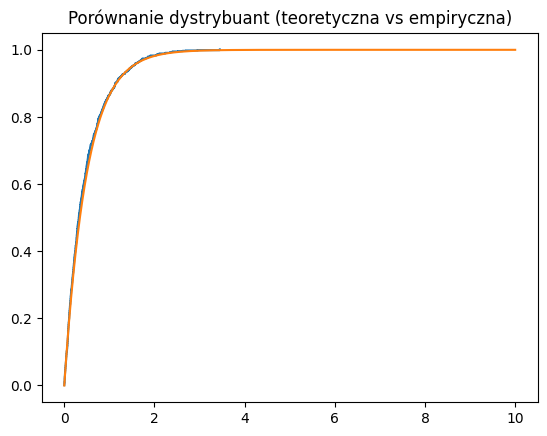

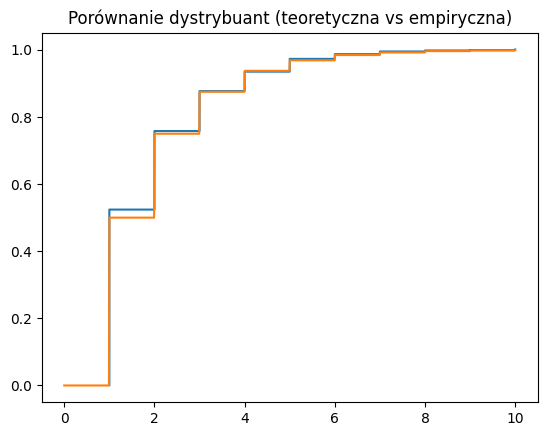

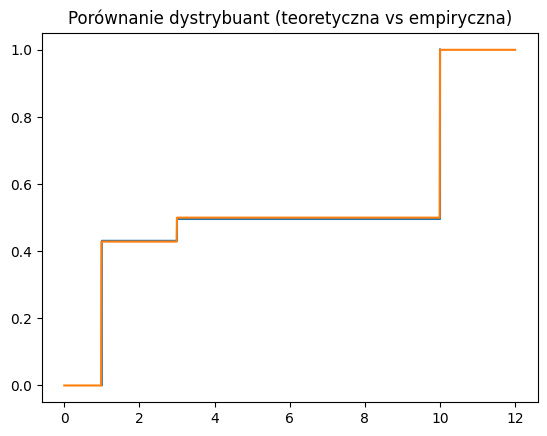

In [414]:
F_exp = []
F_geo = []
# liczę 'ręcznie' dystrybuantę dla rozkładu zadanego prawdopodobieństwem p_k
x = 0.0
F_prob = []
x_prob = np.arange(0.0, 12.01, 0.01)
while x <= 12:
    x += 0.01
    F_prob.append(defined_distr(x))

for x in x1:
    F_exp.append(exp_distr(x, 2))
    F_geo.append(sc.stats.geom.cdf(x, 0.5))

F = [F_exp, F_geo, F_prob]
for i in range(2):
    drawdemp(Y[i], '')
    plt.plot(x_theory[0], F[i])
    plt.title('Porównanie dystrybuant (teoretyczna vs empiryczna)')
    plt.show()

drawdemp(Y[2], '')
plt.plot(x_prob, F_prob)
plt.title('Porównanie dystrybuant (teoretyczna vs empiryczna)')
plt.show()


### 3. Wykres kwantylowy (QQ PLOT)

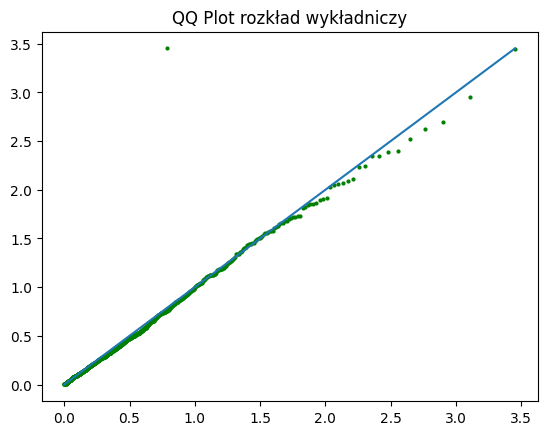

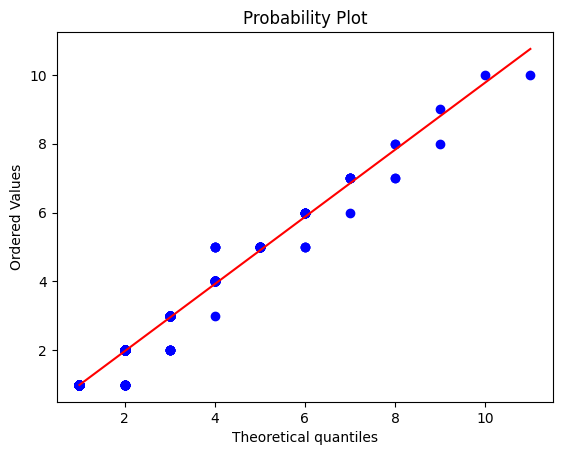

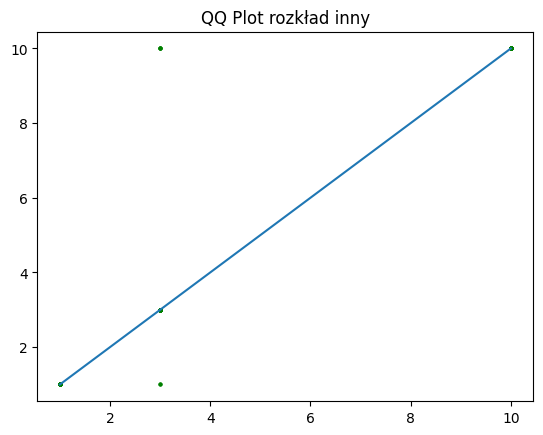

In [415]:
drawqq(Y[0], F_E, 'QQ Plot rozkład wykładniczy')
sc.stats.probplot(Y[1], dist=sc.stats.geom, sparams=(0.5,), plot=plt)
plt.show()
drawqq(Y[2], defined_distr, 'QQ Plot rozkład inny')

### 4. Policz średnią i wariancję próbkową; porównaj je z wartościami teoretycznymi.

Rozkład wykładniczy:
$$
E[X] = \frac{1}{\lambda}, \quad Var(X) = \frac{1}{\lambda^2}
$$
$$ E[x] = {\frac{1}{2}}, \quad Var(X) = \frac{1}{4} $$
Rozkład geometryczny:
$$
E[X] = \frac{1}{p}, \quad Var(X) = \frac{1-p}{p^2}
$$
$$ E[x] = {\frac{1}{0.5} = 2}, \quad Var(X) = \frac{0.5}{0.25} = 2$$

Rozkład zadany prawdopodobieństwem p_k. 
Żeby policzyć ten wzór, musimy skorzystać z definicji (nie ma jawnego wzoru).
$$
E[X] = \sum_{i=1}^{N} x_ip_i = \frac{3}{7} \cdot 1 + \frac{1}{14} \cdot 3 + \frac{1}{2} \cdot 10 =
$$
$$
= \frac{6}{14} + \frac{3}{14} + \frac{70}{14} = \frac{79}{14} \approx 5,64
$$
$$ Var[X] = E[X^2] - (E[X])^2 $$
$$ E[X^2] = \sum_{i=1}^{N} (x_i)^2p_i = \frac{3}{7} \cdot 1^2 + \frac{1}{14} \cdot 3^2 + \frac{1}{2} \cdot 10^2
$$
$$
E[X^2] = \frac{6}{14} + \frac{9}{14} + 50 = \frac{15}{14} + 50 \approx 51,07
$$
$$
Var[X] \approx 51,07 - 5,64^2 \approx 19,26
$$


In [416]:
print(f'Wartość średnia dla rozkładu wykładniczego wynosi: {np.mean(Y[0]):.2f}, wariancja {np.var(Y[0]):.2f}')
print(f'Wartość średnia dla rozkładu geometrycznego wynosi: {np.mean(Y[1]):.2f}, wariancja {np.var(Y[1]):.2f}')
print(f'Wartość średnia dla rozkładu zadanego prawdopodobieńswem p_k wynosi: {np.mean(Y[2]):.2f}, wariancja {np.var(Y[2]):.2f}')

Wartość średnia dla rozkładu wykładniczego wynosi: 0.49, wariancja 0.24
Wartość średnia dla rozkładu geometrycznego wynosi: 1.96, wariancja 1.92
Wartość średnia dla rozkładu zadanego prawdopodobieńswem p_k wynosi: 5.67, wariancja 19.31


### 5. Wykonaj wybrane testy zgodności. (Test Cramera)

Kryterium Cramera polega na zestawieniu danych, którym przypisujemy pochodzenie z jakiegoś rozkładu z tym rozkładem. W teście Cramera interesuje nas  wartość średnia różnicy między dwoma dystrybuantami (empiryczną i teoretyczną). W przypadku, kiedy ta wartość jest mała możemy powiedzieć, że dane faktycznie pochodzą z rozkładu. Wzoru możemy używać dla zarówno rozkładów ciągłych, jak i dyskretnych, ale w przypadku rozkładów dyskretnych popularniejsze są np metody chi-kwadrat.

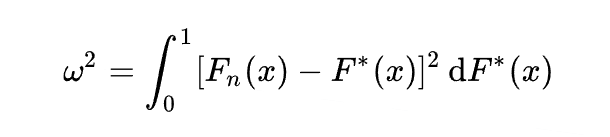

Dla rozkładów ciągłych wzór wygląda tak:


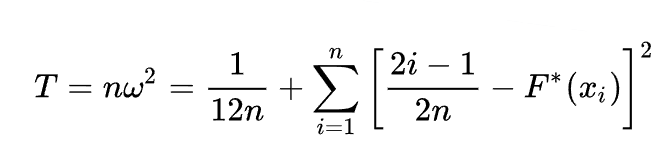


Dla rozkładów dyskretnych, wzór wygląda tak:


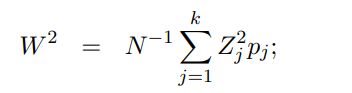
$$ Z_j = (S_j - T_j) $$
$$ T_j = N \cdot F_0(x_i) $$
$$ S_j = N \cdot E[X <= x_i] $$

In [417]:
def CvM_test_continuous(X, F_0):
    n = len(X)
    W_n = 1 / (12 * n)
    X = np.sort(X)
    for i in range(n):
        x_i = X[i]
        W_n += (F_0(x_i) - (2*i - 1)/(2 * n))**2
    return W_n

def CvM_test_discrete(X, F_0, support = np.arange(1, 51), dx = 1):
    n = len(X)
    X = np.sort(X)
    W_n = 0
    for x_i in support:
        p_i = F_0(x_i) - F_0(x_i - dx)
        if p_i > 0:
            F_xi = np.mean(X <= x_i)
            W_n += (F_xi - F_0(x_i))**2 * p_i
    return W_n * n


In [418]:
test_exp = CvM_test_continuous(Y[0], F_E)
test_geo = CvM_test_discrete(Y[1], F_G)
test_other = CvM_test_discrete(Y[2], defined_distr, [1, 3, 10])
print(f'Wyniki zgodności dla rozkładu wykładniczego: {test_exp:.3f}')
print(f'Wyniki zgodności dla rozkładu geometrycznego: {test_geo:.3f}')
print(f'Wyniki zgodności dla rozkładu innego: {test_other:.3f}')

Wyniki zgodności dla rozkładu wykładniczego: 0.186
Wyniki zgodności dla rozkładu geometrycznego: 0.278
Wyniki zgodności dla rozkładu innego: 0.003


### Porównanie czasowe


In [397]:
import time

times_theory = []
times_generated = []
N = 100000

for i in range(3):
    start_theory = time.perf_counter()
    my_data = [rev_distr(F1, random.random(), a=0) for _ in range(N)]
    time_theory = time.perf_counter() - start_theory

    times_theory.append(time_theory)
    start_generated = time.perf_counter()

    data = sc.stats.expon(scale = 1).rvs(size=N)
    time_generated = time.perf_counter() - start_generated
    times_generated.append(time_generated)


print(f'Porównanie średnich czasów wykonania funkcji (rozkład wykładniczy): {np.mean(times_theory):.2e}, {np.mean(times_generated):.2e}')

times_theory = []
times_generated = []
for i in range(3):
    start_theory = time.perf_counter()
    my_data = [rev_discrete_distr(F4, random.random(), a=0) for _ in range(N)]
    time_theory = time.perf_counter() - start_theory

    times_theory.append(time_theory)
    start_generated = time.perf_counter()

    data = sc.stats.geom(p = 1/2).rvs(size=N)
    time_generated = time.perf_counter() - start_generated
    times_generated.append(time_generated)

print(f'Porównanie średnich czasów wykonania funkcji (rozkład geometryczny): {np.mean(times_theory):.2e}, {np.mean(times_generated):.2e}')

values = [1, 2, 3]
probs = [0.2, 0.5, 0.3]
times_theory = []
times_generated = []
for i in range(3):
    start_theory = time.perf_counter()
    my_data = [fixed_prob(prob_table) for _ in range(N)]
    time_theory = time.perf_counter() - start_theory

    times_theory.append(time_theory)
    start_generated = time.perf_counter()

    data = np.random.choice(values, p = probs,size=N)
    time_generated = time.perf_counter() - start_generated
    times_generated.append(time_generated)

print(f'Porównanie średnich czasów wykonania funkcji (inny rozkład): {np.mean(times_theory):.2e}, {np.mean(times_generated):.2e}')


Porównanie średnich czasów wykonania funkcji (rozkład wykładniczy): 1.85e+00, 2.58e-03
Porównanie średnich czasów wykonania funkcji (rozkład geometryczny): 3.82e-01, 2.76e-03
Porównanie średnich czasów wykonania funkcji (inny rozkład): 1.35e-02, 1.63e-03


### Zadanie 8 – VaR jako odwrotna dystrybuanta

In [398]:
def logistic_distr(x, mi, s):
    return 0.5* (1 + np.tanh((x - mi) / (2 * s)))

In [399]:
alfa_1 = 0.01
alfa_2 = 0.001
W_0 = 5e6

F1 = lambda x: norm_distr(x, 0.0003, 0.015) # albo **2?
F2 = lambda x: cauchy_distr(x, 0.0003, 0.008)
F3 = lambda x: logistic_distr(x, 0.0003, 0.008)

y1_1 = rev_distr(F1, alfa_1)
y2_1 = rev_distr(F2, alfa_1)
y3_1 = rev_distr(F3, alfa_1)

y1_2 = rev_distr(F1, alfa_2)
y2_2 = rev_distr(F2, alfa_2)
y3_2 = rev_distr(F3, alfa_2)

tab1 = [y1_1, y2_1, y3_1]
tab2 = [y1_2, y2_2, y3_2]

tab1 = [round(abs(x) * W_0, 2) for x in tab1]
tab2 = [round(abs(x) * W_0, 2) for x in tab2]

print(tab1)
print(tab2)


[173226.0, 1272186.64, 180676.58]
[229105.35, 12731179.59, 273808.84]


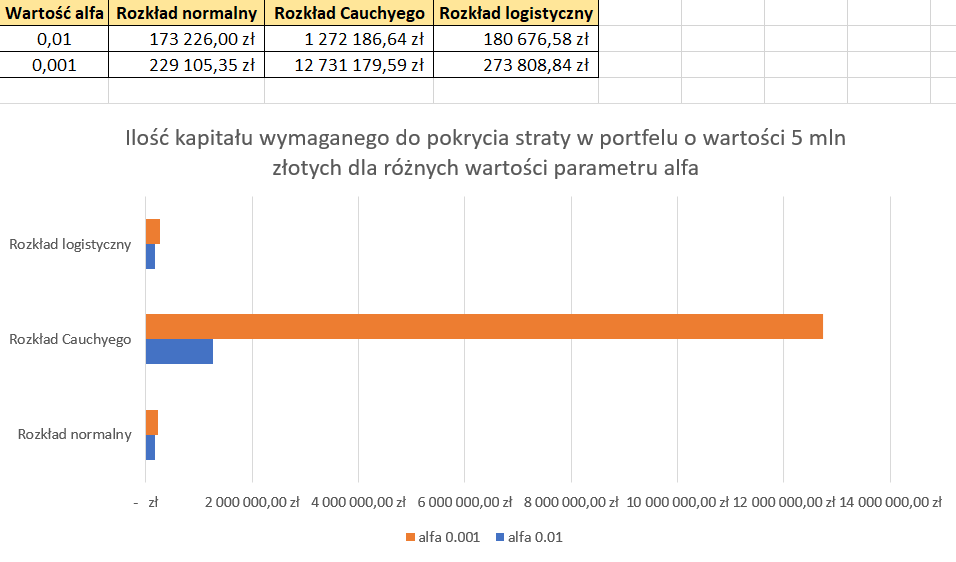

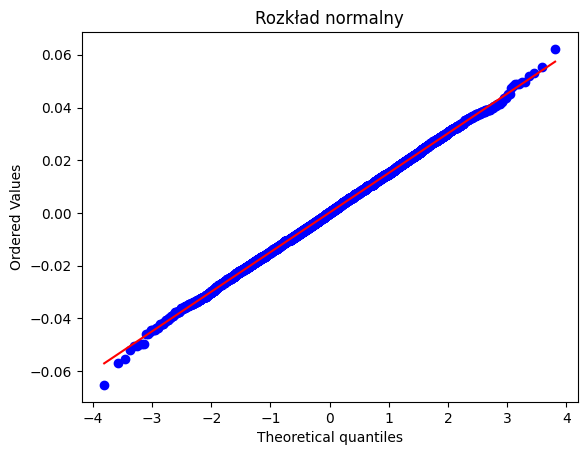

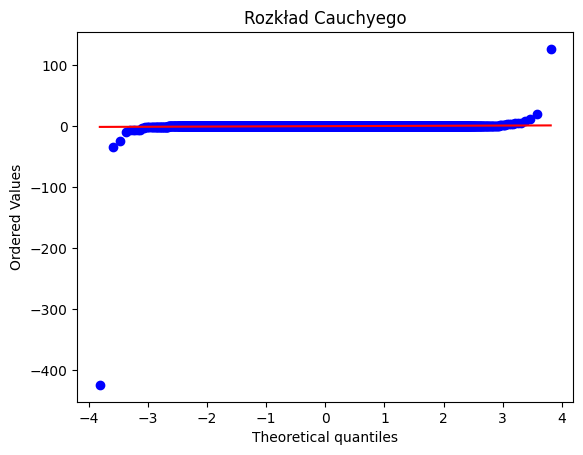

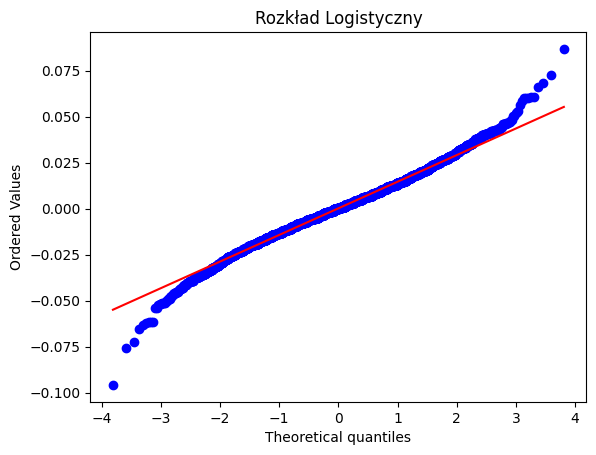

In [400]:
n = 10000
U = np.random.random(n)

N = []
C = []
L = []

for u in U:
    N.append(rev_distr(F1, u))
    C.append(rev_distr(F2, u))
    L.append(rev_distr(F3, u))

sc.stats.probplot(N, dist='norm', plot=plt)
plt.title('Rozkład normalny')
plt.show()
sc.stats.probplot(C, dist='norm', plot=plt)
plt.title('Rozkład Cauchyego')
plt.show()
sc.stats.probplot(L, dist='norm', plot=plt)
plt.title('Rozkład Logistyczny')
plt.show()
